In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization, Dropout, Dense, Flatten,
    Bidirectional, LSTM, GlobalAveragePooling1D, MultiHeadAttention
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    CSVLogger, EarlyStopping, ReduceLROnPlateau, TerminateOnNaN
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical


2026-05-02 17:57:06.435602: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777744626.633645      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777744626.690950      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777744627.136688      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777744627.136752      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777744627.136755      23 computation_placer.cc:177] computation placer alr

In [2]:
!nvidia-smi

Sat May  2 17:57:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

file_paths = []
for root, dirs, filenames in os.walk('/kaggle/input/ids-intrusion-csv'):
    for filename in filenames:
        file_paths.append(os.path.join(root, filename))
        
file_paths.remove('/kaggle/input/ids-intrusion-csv/02-20-2018.csv')
print("Number of input files:", len(file_paths))

def load_data(file_paths):
    combined_df = pd.DataFrame()
    for file in file_paths:
        print("Loading:", file)
        data = pd.read_csv(file, low_memory=False)
        
        combined_df = pd.concat([combined_df, data], ignore_index=True, copy=False)

    return combined_df.drop(columns=["Timestamp"])

df = load_data(file_paths)

print("--- Counts before filtering ---")
print(df['Label'].value_counts())

df = df[df['Label'] == 'Benign']

def clean_data(data):
    encoder = LabelEncoder()
    data['Label'] = encoder.fit_transform(data['Label']) 
    data = data.apply(pd.to_numeric, errors='coerce') 
    data = data.replace([np.inf, -np.inf], np.nan) 
    data = data.dropna()
    return pd.DataFrame(data), encoder

df, encoder = clean_data(df)

if len(df) > 40000:
    df = df.sample(n=40000, random_state=42)

print("--- Counts after filtering and cleaning ---")
print(df['Label'].unique())
print(df['Label'].value_counts())

df.to_csv('/kaggle/working/cleaned_benign_only.csv', index=False)

Number of input files: 9
Loading: /kaggle/input/ids-intrusion-csv/02-28-2018.csv
Loading: /kaggle/input/ids-intrusion-csv/03-01-2018.csv
Loading: /kaggle/input/ids-intrusion-csv/02-16-2018.csv
Loading: /kaggle/input/ids-intrusion-csv/02-15-2018.csv
Loading: /kaggle/input/ids-intrusion-csv/02-21-2018.csv
Loading: /kaggle/input/ids-intrusion-csv/03-02-2018.csv
Loading: /kaggle/input/ids-intrusion-csv/02-22-2018.csv
Loading: /kaggle/input/ids-intrusion-csv/02-14-2018.csv
Loading: /kaggle/input/ids-intrusion-csv/02-23-2018.csv
--- Counts before filtering ---
Label
Benign                      6112151
DDOS attack-HOIC             686012
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193360
SSH-Bruteforce               187589
Infilteration                161934
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
B

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import RobustScaler

def preprocess_for_anomaly(data, test_size=0.2, random_state=42):
    X = data.drop('Label', axis=1)    
    X_train, X_test = train_test_split(X, test_size=test_size, random_state=random_state)
    selector = VarianceThreshold(threshold=0.01)
    X_train_filtered = selector.fit_transform(X_train)
    X_test_filtered  = selector.transform(X_test)
    scaler = RobustScaler(quantile_range=(5, 95))
    X_train_ml = scaler.fit_transform(X_train_filtered)
    X_test_ml  = scaler.transform(X_test_filtered)
    X_train_cnn = X_train_ml[..., np.newaxis]
    X_test_cnn  = X_test_ml[..., np.newaxis]

    return X_train_cnn, X_test_cnn

X_train_cnn, X_test_cnn = preprocess_for_anomaly(df, test_size=0.2, random_state=42)

print("\nFinal dataset shapes:")
print(f"X_train_cnn (3D): {X_train_cnn.shape}")
print(f"X_test_cnn  (3D): {X_test_cnn.shape}")


Final dataset shapes:
X_train_cnn (3D): (32000, 67, 1)
X_test_cnn  (3D): (8000, 67, 1)


In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, UpSampling1D, 
                                     BatchNormalization, Dropout, Bidirectional, 
                                     LSTM, MultiHeadAttention, Dense, Add, 
                                     LayerNormalization, RepeatVector, Concatenate)
from tensorflow.keras.regularizers import l2

def build_zero_day_detector(input_shape):
    inputs = Input(shape=input_shape, name="input_data")
    x = Conv1D(128, 5, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2, padding='same')(x)
    x = Dropout(0.2)(x)
    x = Conv1D(64, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2, padding='same')(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = LayerNormalization()(x)
    attn_out = MultiHeadAttention(num_heads=8, key_dim=32)(x, x)
    x = Add()([x, attn_out])
    x = LayerNormalization()(x)
    x = Bidirectional(LSTM(32, return_sequences=False))(x) 
    x = Dropout(0.2)(x)
    x = RepeatVector(input_shape[0])(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = LayerNormalization()(x)
    x = Conv1D(128, 3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    outputs = Dense(input_shape[1], activation='linear', name="reconstruction")(x)
    model = Model(inputs, outputs, name="Deep_ZeroDay_Autoencoder")
    return model

input_dim = (X_train_cnn.shape[1], X_train_cnn.shape[2])
autoencoder = build_zero_day_detector(input_dim)
autoencoder.compile(optimizer='adam', loss='mae')
autoencoder.summary()

I0000 00:00:1777745079.152971      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Deep_ZeroDay_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_data          │ (None, 67, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 67, 128)   │        768 │ input_data[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 67, 128)   │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 34, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 34, 128)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 34, 64)    │     24,640 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 34, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 17, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 17, 128)   │     66,048 │ max_pooling1d_1[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 17, 128)   │        256 │ bidirectional[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 17, 128)   │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 17, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 17, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     41,216 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 67, 64)    │          0 │ dropout_2[0][0]   │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 67, 128)   │     66,048 │ repeat_vector[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 67, 128)   │        256 │ bidirectional_2[… │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 382,145 (1.46 MB)

 Trainable params: 381,505 (1.46 MB)

 Non-trainable params: 640 (2.50 KB)

In [6]:
batch_size = 256

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_cnn, X_train_cnn))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train_cnn))
train_dataset = train_dataset.batch(batch_size)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_cnn, X_test_cnn))
test_dataset = test_dataset.batch(batch_size)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

Training CNN+BiLSTM+Attention as Autoencoder for Zero-day Detection...
Epoch 1/50


I0000 00:00:1777745090.090256      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 1.0415 - val_loss: 0.4137 - learning_rate: 1.0000e-04
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.5232 - val_loss: 0.3703 - learning_rate: 1.0000e-04
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.4744 - val_loss: 0.3908 - learning_rate: 1.0000e-04
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.4240 - val_loss: 0.4057 - learning_rate: 1.0000e-04
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.4124 - val_loss: 0.4046 - learning_rate: 1.0000e-04
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.4346 - val_loss: 0.3887 - learning_rate: 2.0000e-05
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.4409 - val_loss: 0.3903 - learning_rate: 2.0000e-05
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.4496 - val_loss: 0.3838 - learning_rate: 2.0000e-05
Model trained in 65.64 seconds


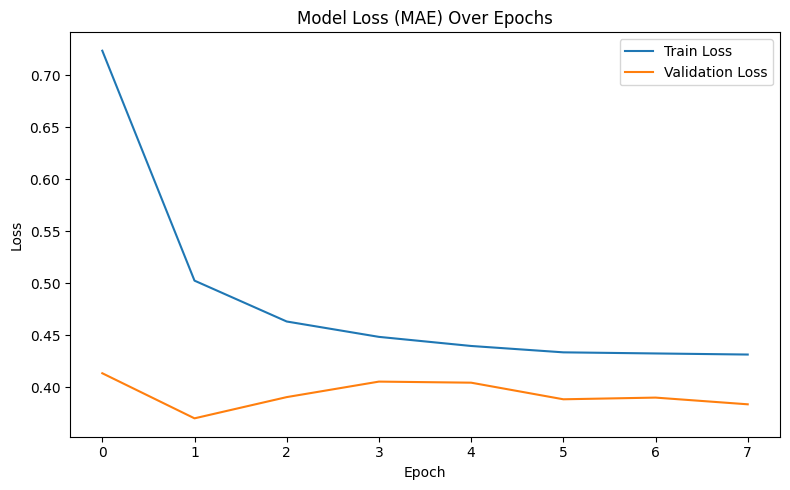

In [7]:
lr = 1e-4
optimizer = Adam(learning_rate=lr)

autoencoder.compile(
    optimizer=optimizer,
    loss='mae'
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    tf.keras.callbacks.TerminateOnNaN()
]

start_time = time.time()
with tf.device('/GPU:0'):
    print("Training CNN+BiLSTM+Attention as Autoencoder for Zero-day Detection...")
    history_attn = autoencoder.fit(
        train_dataset,
        epochs=50,
        validation_data=(X_test_cnn, X_test_cnn),
        callbacks=callbacks,
        verbose=1
    )
training_time = time.time() - start_time

print(f"Model trained in {training_time:.2f} seconds")
def plot_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss (MAE) Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_attn)

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

X_test_pred = autoencoder.predict(X_test_cnn)
reconstruction_errors = np.mean(np.abs(X_test_cnn - X_test_pred), axis=(1, 2))
threshold = np.mean(reconstruction_errors) + 2 * np.std(reconstruction_errors) 
print(f"Threshold set at: {threshold}")
y_pred_binary = [1 if e > threshold else 0 for e in reconstruction_errors]
y_true = np.zeros(len(y_pred_binary))
acc = accuracy_score(y_true, y_pred_binary)
prec = precision_score(y_true, y_pred_binary, zero_division=0)
rec = recall_score(y_true, y_pred_binary, zero_division=0)
f1 = f1_score(y_true, y_pred_binary, zero_division=0)

print("\n=== Anomaly Detection Metrics (Testing on Benign Only) ===")
print(f"Accuracy (Normal Data Recognition): {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall: {rec*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")
print("\nClassification Report")
print(classification_report(y_true, y_pred_binary, target_names=['Benign', 'Attack'], labels=[0, 1], zero_division=0))

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Threshold set at: 2.3673907857944023

=== Anomaly Detection Metrics (Testing on Benign Only) ===
Accuracy (Normal Data Recognition): 98.56%
Precision: 0.00%
Recall: 0.00%
F1-Score: 0.00%

Classification Report
              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99      8000
      Attack       0.00      0.00      0.00         0

    accuracy                           0.99      8000
   macro avg       0.50      0.49      0.50      8000
weighted avg       1.00      0.99      0.99      8000

